# Unsupervised Foundation Shade Clustering

This notebook trains K-Means on product LAB values to explore whether the
catalogue contains naturally separated colour groups. Clustering is an
optional candidate-filtering experiment; CIEDE2000 remains the final
ranking method.


## 1. Setup


In [17]:
from pathlib import Path
import os
import subprocess
import sys

REPOSITORY_URL = "https://github.com/amafteeva/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-.git"


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


project_root = find_project_root(Path.cwd())

if project_root is None and "google.colab" in sys.modules:
    project_root = Path("/content/foundation-shade-recommender")
    if not project_root.exists():
        subprocess.run(["git", "clone", REPOSITORY_URL, str(project_root)], check=True)

if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the project folder.")

os.chdir(project_root)

# Connect the local `foundation_matcher` package (src/ layout) so the
# imports below resolve even if the editable install has not been run.
src_path = project_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Install the package and its dependencies. Non-fatal: if a dependency
# wheel is unavailable the local package is still importable via src_path.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "."],
    check=False,
)
if result.returncode != 0:
    print("Warning: `pip install -e .` failed; using src/ on sys.path instead.")

import importlib.util

if importlib.util.find_spec("foundation_matcher") is None:
    raise ModuleNotFoundError(
        f"foundation_matcher not found. Expected package at {src_path}."
    )

print("Project root:", project_root)
print("foundation_matcher connected from:", src_path)


Project root: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-
foundation_matcher connected from: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-/src


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from foundation_matcher.data import load_foundation_catalog
from foundation_matcher.recommender import (
    evaluate_cluster_counts,
    fit_shade_clusters,
    recommend_foundations,
    recommend_foundations_clustered,
)
from foundation_matcher.visualization import (
    plot_cluster_metrics,
    plot_shade_clusters,
)


## 2. Compare candidate values of K


,clusters,silhouette_score,davies_bouldin_score
0,2,0.506,0.772
1,3,0.427,0.817
2,4,0.351,0.907
3,5,0.314,1.015
4,6,0.319,1.001
5,7,0.290,1.065
6,8,0.294,1.045
7,9,0.286,1.065
8,10,0.290,1.040
9,11,0.286,1.050


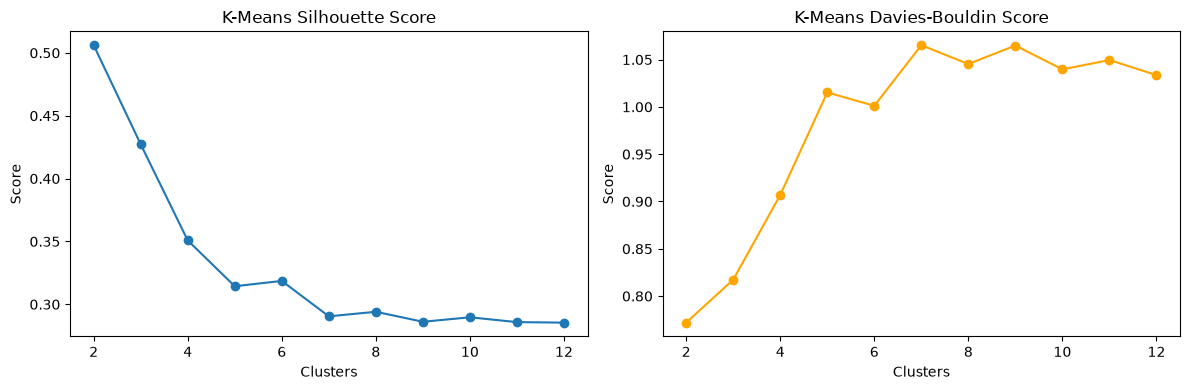

In [19]:
products = load_foundation_catalog()
cluster_evaluation = evaluate_cluster_counts(products, range(2, 13))
display(cluster_evaluation.round(3))

plot_cluster_metrics(cluster_evaluation)
plt.show()


Silhouette score is better when higher; Davies-Bouldin score is better
when lower. A mathematically strong K is not automatically the most useful
business segmentation, especially if a small K only separates light and
dark shades. Interpret cluster centres and sizes before assigning meaning.


In [20]:
best_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["silhouette_score"].idxmax(),
        "clusters",
    ]
)
print("Best K by silhouette score:", best_k)

cluster_model, clustered_products = fit_shade_clusters(products, best_k)
display(
    clustered_products["shade_cluster"]
    .value_counts()
    .sort_index()
    .rename("products")
    .to_frame()
)


Best K by silhouette score: 2


,products
shade_cluster,
0,404
1,221


## 3. Compare global and cluster-restricted ranking

The example below uses a synthetic LAB input so the notebook is
reproducible without a personal selfie. The clustered method predicts one
group first, then ranks products within it. Compare it with the global
baseline because cluster boundaries can exclude a genuinely close colour.


In [21]:
example_skin_lab = np.array([65.0, 12.0, 18.0])

global_matches = recommend_foundations(
    example_skin_lab,
    products,
    top_n=5,
)
predicted_cluster, clustered_matches = recommend_foundations_clustered(
    example_skin_lab,
    clustered_products,
    cluster_model,
    top_n=5,
)

print("Predicted shade cluster:", predicted_cluster)
print("\nGlobal CIEDE2000 ranking")
display(global_matches[["brand", "product", "hex", "color_distance"]])
print("\nCluster-restricted ranking")
display(
    clustered_matches[
        ["brand", "product", "hex", "shade_cluster", "color_distance"]
    ]
)


Predicted shade cluster: 0

Global CIEDE2000 ranking


,brand,product,hex,color_distance
0,Maybelline,Fit Me,C09578,2.096432
1,Make Up For Ever,Ultra HD,C7977B,2.394669
2,L'Oréal,True Match,C29979,3.497200
3,Laws of Nature,Foxy Finish,BB8F7F,3.774523
4,Revlon,ColorStay,C68F71,3.950705



Cluster-restricted ranking


,brand,product,hex,shade_cluster,color_distance
0,Maybelline,Fit Me,C09578,0,2.096432
1,Make Up For Ever,Ultra HD,C7977B,0,2.394669
2,L'Oréal,True Match,C29979,0,3.497200
3,Laws of Nature,Foxy Finish,BB8F7F,0,3.774523
4,Revlon,ColorStay,C68F71,0,3.950705


## 4. Conclusion

Treat K-Means as an interpretable exploratory model, not evidence that it
improves recommendations. To claim improvement, compare both methods
against independent, professionally labelled foundation matches.
